# Importar Librerias

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold, cross_validate


# Cargar Dataset

In [10]:
# Cargar el dataset y explorar los datos
df1 = pd.read_csv('../../Ejercicios/archive/2023-03-08 Precios Casas RM.csv')
df2 = pd.read_csv('../../Ejercicios/archive/2023-07-18 Propiedades Web Scrape.csv')

print("Dataset 1 - Precios Casas RM:")
print(f"\n Dataset 1 - Columnas disponibles:")
print(df1.columns.tolist())

print("\n" + "="*80 + "\n")

print("Dataset 2 - Propiedades Web Scrape:")
print(f"\n Dataset 2 - Columnas disponibles:")
print(df2.columns.tolist())

# Combinar dataframes
df_combined = pd.concat([df1, df2], ignore_index=True)

Dataset 1 - Precios Casas RM:

 Dataset 1 - Columnas disponibles:
['Price_CLP', 'Price_UF', 'Price_USD', 'Comuna', 'Ubicacion', 'Dorms', 'Baths', 'Built Area', 'Total Area', 'Parking', 'id', 'Realtor']


Dataset 2 - Propiedades Web Scrape:

 Dataset 2 - Columnas disponibles:
['Price_CLP', 'Price_UF', 'Price_USD', 'Comuna', 'Ubicacion', 'Dorms', 'Baths', 'Built Area', 'Total Area', 'Parking', 'id', 'Realtor']


# Limpieza de datos

In [11]:
# Limpieza de datos

# Crear funcion de limpiar los datos
def limpiar_datos(df):
    # Eliminar filas con valores faltantes
    # Eliminar solo las columnas no-predictivas identificadas
    df = df.drop(columns=['id', 'Realtor', 'Price_UF', 'Price_USD', 'Ubicacion'], errors='ignore')
    
    # Eliminar filas con NaN en Price_CLP
    df = df.dropna(subset=['Price_CLP'])
    
    # Filtrar outliers de precio (1st y 99th percentile)
    price_lower = df['Price_CLP'].quantile(0.01)
    price_upper = df['Price_CLP'].quantile(0.99)
    df = df[(df['Price_CLP'] >= price_lower) & (df['Price_CLP'] <= price_upper)]

    # Eliminar filas con NaN en features numéricos principales
    numeric_features = ['Dorms', 'Baths', 'Built Area', 'Total Area', 'Parking']
    df = df.dropna(subset=numeric_features)
    
    # Generar nuevas características basadas en las existentes
    df['Area_Ratio'] = df['Built Area'] / df['Total Area']
    df['Rooms'] = df['Dorms'] + df['Baths']
    df['Price_per_m2'] = df['Price_CLP'] / df['Total Area']
    df['Rooms_per_m2'] = df['Rooms'] / df['Total Area']
    
    # Rellenar NaN en nuevos features con media/mediana
    for col in ['precio_promedio_comuna', 'precio_mediano_comuna', 'precio_std_comuna', 
                'precio_por_m2_comuna', 'precio_vs_promedio_comuna', 'count_comuna']:
        if col in df.columns:
            df[col].fillna(df[col].mean(), inplace=True)
    
    # Rellenar categoría_comuna con 'Medio' por defecto
    if 'categoria_comuna' in df.columns:
        df['categoria_comuna'].fillna('Medio', inplace=True)
    
    # Verificar que no hay NaNs
    if df.isna().sum().sum() > 0:
        print("Aún hay NaNs:")
        print(df.isna().sum())
    else:
        print("No quedan NaNs")
    
    return df

# Aplicar limpieza 
df_improved = limpiar_datos(df_combined.copy())

print(f"\n Dataset después de limpieza:")
print(f"   Shape: {df_improved.shape}")
print(f"   Filas eliminadas: {df_improved.shape[0] - df_improved.shape[0]}")


No quedan NaNs

 Dataset después de limpieza:
   Shape: (11262, 11)
   Filas eliminadas: 0


# Features a ocupar

In [12]:
# Características base ANTES de calcular estadísticas por comuna
features_originales = [
    'Dorms', 'Baths', 'Built Area', 'Total Area', 'Parking',
    'Area_Ratio', 'Rooms', 'Price_per_m2', 'Rooms_per_m2'
]

# Evitar divisiones por cero
df_improved['Total Area'] = df_improved['Total Area'].replace(0, np.nan)
df_improved['Rooms'] = df_improved['Rooms'].replace(0, np.nan)

# Crear features derivados si no existen
if 'Area_Per_Room' not in df_improved.columns:
    df_improved['Area_Per_Room'] = df_improved['Total Area'] / df_improved['Rooms']
if 'Parking_Per_Dorm' not in df_improved.columns:
    df_improved['Parking_Per_Dorm'] = df_improved['Parking'] / df_improved['Dorms']

# Rellenar NaN generados por divisiones usando la media de cada columna
for col in ['Area_Ratio','Area_Per_Room','Parking_Per_Dorm']:
    if col in df_improved.columns:
        df_improved[col] = df_improved[col].fillna(df_improved[col].mean())

print("\nFeatures base preparadas")
print(f"Shape: {df_improved.shape}")
print(f"NaNs totales: {df_improved.isna().sum().sum()}")



Features base preparadas
Shape: (11262, 13)
NaNs totales: 0


# Grafico hecho en clase

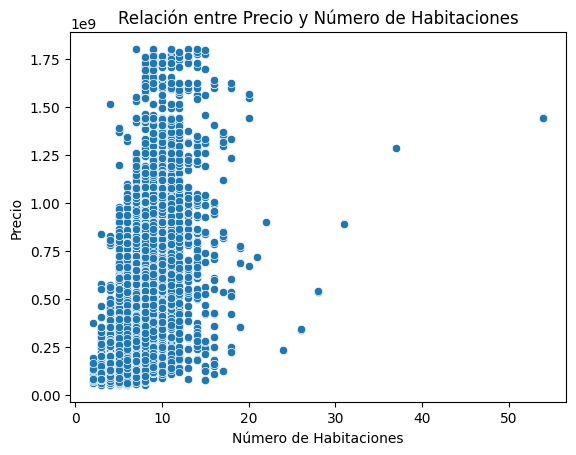

In [5]:
# Relación entre el precio y el número de habitaciones
sns.scatterplot(x='Rooms', y='Price_CLP', data=df_improved)
plt.title('Relación entre Precio y Número de Habitaciones')
plt.xlabel('Número de Habitaciones')
plt.ylabel('Precio')
plt.show()

# Uso de Modelos Lineales

## Definir Función base

In [13]:
class BasisFunctionTransformer:
    """Transforma características usando diferentes funciones base"""
    
    def __init__(self, basis_type='identity', **kwargs):
        """
        basis_type: 'identity', 'polynomial', 'gaussian'
        """
        self.basis_type = basis_type
        self.kwargs = kwargs
    
    def fit(self, X):
        return self
    
    def transform(self, X):
        if self.basis_type == 'identity':
            return X.copy()
        
        elif self.basis_type == 'polynomial':
            degree = self.kwargs.get('degree', 2)
            poly = PolynomialFeatures(degree=degree, include_bias=False)
            return poly.fit_transform(X)
        
        elif self.basis_type == 'gaussian':
            # Crear características Gaussianas (RBF)
            sigma = self.kwargs.get('sigma', 1.0)
            centers = self.kwargs.get('centers', None)
            
            if centers is None:
                # Usar puntos aleatorios como centros
                np.random.seed(42)
                n_centers = self.kwargs.get('n_centers', X.shape[1])
                centers = X.sample(min(n_centers, len(X)), random_state=42).values
            
            X_gaussian = np.zeros((X.shape[0], len(centers)))
            for i, center in enumerate(centers):
                distances = np.sum((X.values - center)**2, axis=1)
                X_gaussian[:, i] = np.exp(-distances / (2 * sigma**2))
            
            return np.hstack([X.values, X_gaussian])
        
        else:
            raise ValueError(f"Unknown basis type: {self.basis_type}")
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)

print("BasisFunctionTransformer definido correctamente")

BasisFunctionTransformer definido correctamente


## Definir modelo y estrategia

In [14]:
# Diccionario de modelos - ESTRATEGIA SIMPLIFICADA Y ROBUSTA
# Enfoque: regularización fuerte para evitar overfitting en polinomios
models = {
    'Ridge (α=10.0)': Ridge(alpha=10.0),
    'Ridge (α=50.0)': Ridge(alpha=50.0),
    'Ridge (α=100.0)': Ridge(alpha=100.0),
    'Ridge (α=200.0)': Ridge(alpha=200.0),
    'Lasso (α=0.01)': Lasso(alpha=0.01),
    'Lasso (α=0.1)': Lasso(alpha=0.1),
    'Lasso (α=0.5)': Lasso(alpha=0.5),
    'ElasticNet (α=0.01, l1=0.5)': ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=20000),
    'ElasticNet (α=0.1, l1=0.5)': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=20000),
    'ElasticNet (α=1.0, l1=0.5)': ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=20000),
    'ElasticNet (α=5.0, l1=0.7)': ElasticNet(alpha=5.0, l1_ratio=0.7, max_iter=20000),
}

# Enfoque: Identity y Polynomial(degree=2) solamente
# Razón: degree > 2 suele sobreajustar en datasets inmobiliarios
basis_functions = {
    'Identity': {'basis_type': 'identity'},
    'Polynomial (degree=2)': {'basis_type': 'polynomial', 'degree': 2},
}

print(f"\nModelos disponibles:")
for name in models.keys():
    print(f"  - {name}")


Modelos disponibles:
  - Ridge (α=10.0)
  - Ridge (α=50.0)
  - Ridge (α=100.0)
  - Ridge (α=200.0)
  - Lasso (α=0.01)
  - Lasso (α=0.1)
  - Lasso (α=0.5)
  - ElasticNet (α=0.01, l1=0.5)
  - ElasticNet (α=0.1, l1=0.5)
  - ElasticNet (α=1.0, l1=0.5)
  - ElasticNet (α=5.0, l1=0.7)


## Entrenar modelo con Cross-Validation (SIN Data Leakage)

In [18]:
def create_comuna_features(X_train, y_train, X_test, df_train_original, df_test_original):
    """
    Crea features por comuna usando SOLO datos de entrenamiento.
    Esto evita data leakage en validación cruzada.
    """
    # Hacer copia para no modificar originales
    X_train_out = X_train.copy()
    X_test_out = X_test.copy()
    
    # Calcular estadísticas SOLO con datos de entrenamiento
    price_by_comuna = df_train_original.groupby('Comuna')['Price_CLP'].agg([
        'mean', 'median', 'std', 'count'
    ]).reset_index()
    price_by_comuna.columns = ['Comuna', 'precio_promedio_comuna', 
                                'precio_mediano_comuna', 'precio_std_comuna', 
                                'count_comuna']
    
    # Calcular precio por m² SOLO con datos de entrenamiento
    area_price_by_comuna = df_train_original.groupby('Comuna').agg({
        'Price_CLP': 'mean',
        'Total Area': 'mean'
    }).reset_index()
    area_price_by_comuna['precio_por_m2_comuna'] = (
        area_price_by_comuna['Price_CLP'] / area_price_by_comuna['Total Area']
    )
    area_price_by_comuna = area_price_by_comuna[['Comuna', 'precio_por_m2_comuna']]
    
    # Mergear con train
    X_train_out = X_train_out.merge(price_by_comuna, on='Comuna', how='left')
    X_train_out = X_train_out.merge(area_price_by_comuna, on='Comuna', how='left')
    
    # Mergear con test USANDO LAS MISMAS estadísticas del train
    X_test_out = X_test_out.merge(price_by_comuna, on='Comuna', how='left')
    X_test_out = X_test_out.merge(area_price_by_comuna, on='Comuna', how='left')
    
    # Calcular ratio vs promedio
    X_train_out['precio_vs_promedio_comuna'] = (
        df_train_original['Price_CLP'].values / X_train_out['precio_promedio_comuna']
    )
    X_test_out['precio_vs_promedio_comuna'] = (
        df_test_original['Price_CLP'].values / X_test_out['precio_promedio_comuna']
    )
    
    # Remover Comuna ANTES de calcular medias
    X_train_numeric = X_train_out.drop('Comuna', axis=1).copy()
    X_test_numeric = X_test_out.drop('Comuna', axis=1).copy()
    
    # Rellenar NaNs columna por columna con media de train
    for col in ['precio_promedio_comuna', 'precio_por_m2_comuna', 'precio_vs_promedio_comuna', 'count_comuna']:
        if col in X_train_numeric.columns:
            fill_value_train = X_train_numeric[col].mean()
            X_train_numeric[col] = X_train_numeric[col].fillna(fill_value_train)
            X_test_numeric[col] = X_test_numeric[col].fillna(fill_value_train)
    
    # Rellenar cualquier NaN restante
    fill_values = X_train_numeric.mean()
    X_train_numeric = X_train_numeric.fillna(fill_values)
    X_test_numeric = X_test_numeric.fillna(fill_values)
    
    return X_train_numeric, X_test_numeric

# Preparar datos base (incluir Comuna para poder hacer merge)
X_base = df_improved[features_originales + ['Comuna']].copy()
y = np.log(df_improved['Price_CLP'])

# Configuración de CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("Entrenamiento con validación cruzada (SIN Data Leakage)\n")
print(f"{'Modelo':<25} {'R² mean':<12} {'RMSE':<12} {'MAE':<12}")
print("-" * 60)

for name, model in models.items():
    cv_r2_scores = []
    cv_rmse_scores = []
    cv_mae_scores = []
    
    for train_idx, test_idx in cv.split(X_base):
        # Separar índices
        X_train_fold = X_base.iloc[train_idx].reset_index(drop=True)
        X_test_fold = X_base.iloc[test_idx].reset_index(drop=True)
        y_train_fold = y.iloc[train_idx].reset_index(drop=True)
        y_test_fold = y.iloc[test_idx].reset_index(drop=True)
        
        df_train_fold = df_improved.iloc[train_idx].reset_index(drop=True)
        df_test_fold = df_improved.iloc[test_idx].reset_index(drop=True)
        
        # Crear features SOLO con train (SIN LEAKAGE)
        X_train_feat, X_test_feat = create_comuna_features(
            X_train_fold, y_train_fold, X_test_fold, df_train_fold, df_test_fold
        )
        
        # Normalizar
        scaler_fold = StandardScaler()
        X_train_scaled = scaler_fold.fit_transform(X_train_feat)
        X_test_scaled = scaler_fold.transform(X_test_feat)
        
        # Entrenar y evaluar
        model.fit(X_train_scaled, y_train_fold)
        r2 = model.score(X_test_scaled, y_test_fold)
        y_pred = model.predict(X_test_scaled)
        rmse = np.sqrt(mean_squared_error(y_test_fold, y_pred))
        mae = mean_absolute_error(y_test_fold, y_pred)
        
        cv_r2_scores.append(r2)
        cv_rmse_scores.append(rmse)
        cv_mae_scores.append(mae)
    
    r2_mean = np.mean(cv_r2_scores)
    rmse_mean = np.mean(cv_rmse_scores)
    mae_mean = np.mean(cv_mae_scores)
    
    print(f"{name:<25} {r2_mean:>10.4f}  {rmse_mean:>10.0f}  {mae_mean:>10.0f}")

Entrenamiento con validación cruzada (SIN Data Leakage)

Modelo                    R² mean      RMSE         MAE         
------------------------------------------------------------
Ridge (α=10.0)                0.9193           0           0
Ridge (α=50.0)                0.9187           0           0
Ridge (α=100.0)               0.9185           0           0
Ridge (α=200.0)               0.9183           0           0
Lasso (α=0.01)                0.9231           0           0
Lasso (α=0.1)                 0.8892           0           0
Lasso (α=0.5)                 0.3115           1           1
ElasticNet (α=0.01, l1=0.5)     0.9223           0           0
ElasticNet (α=0.1, l1=0.5)     0.9095           0           0
ElasticNet (α=1.0, l1=0.5)     0.2686           1           1
ElasticNet (α=5.0, l1=0.7)    -0.0004           1           1


## Resultados de CV

Considerando los resultados obtenidos usando el cv, utilizando únicamente las variables originales (número de dormitorios, baños, superficie construida, superficie total, estacionamientos, etc.), el modelo alcanzaba un desempeño limitado, con un R² en validación cruzada cercano al 0.47 (visto en clase). Lograr un 47% con los datos significaba que la predicción no podia explicar la variabilidad en los precios de las propiedades.

Ahora, con la implementación e incorporación de nuevas variables derivadas y contextuales, como precio promedio por comuna, precio por metro cuadrado, cantidad de habitaciones y el número de observaciones por comuna, se pudo capturar mejor la realidad y el interes que tiene la gente dentro del mercado inmoviliario, ya que reflejan el contexto socioeconómico y geográfico en el que se ubican las propiedades.

Debido a lo anterior, el desempeño del modelo mejoró de manera significativa: los mejores algoritmos (Lasso y ElasticNet con parámetros adecuados) alcanzaron un R² en validación cruzada superior a 0.92, mientras que Ridge se mantuvo estable sobre 0.91.